<span style='font-size:40px; display:block;'>
<b>
    Air temperature
</b>
</span>

**Author**: Lukas Hörtnagl (holukas@ethz.ch)

# Air temperature variable

In [1]:
ta_col = "TA_T1_2_1"

</br>

# Imports

In [2]:
import importlib.metadata
import warnings
from datetime import datetime
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.cumulative import CumulativeYear
from diive.core.plotting.heatmap_datetime import HeatmapDateTime, HeatmapYearMonth

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.86.0


</br>

# Load data

In [3]:
SOURCEDIR = r"../60_MERGE_DATA_FLUXES"
FILENAME = r"61.1_FLUXES_M10_MGMT_L4.1_NEE_LE_H_FN2O_FCH4.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
df = load_parquet(filepath=FILEPATH)
ta = df[ta_col].copy()

Loaded .parquet file ..\60_MERGE_DATA_FLUXES\61.1_FLUXES_M10_MGMT_L4.1_NEE_LE_H_FN2O_FCH4.parquet (0.767 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


</br>

# List of air temperature variables

In [4]:
# fluxlist = [c for c in df.columns if ("TA_" or "_TA_") in c];
# fluxlist

</br>

# Plots

## Heatmap (half-hourly)

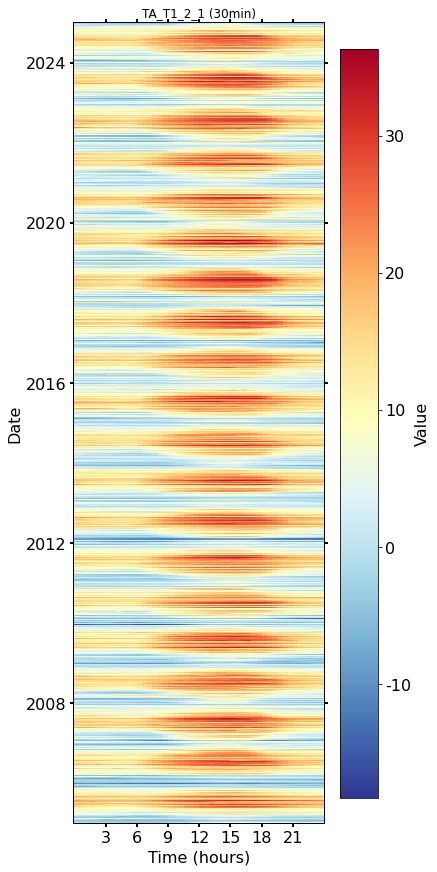

In [5]:
fig, axs = plt.subplots(ncols=1, figsize=(6, 12), dpi=72, layout="constrained")
HeatmapDateTime(series=ta, ax=axs, cb_digits_after_comma=0).plot()

## Heatmaps (monthly)

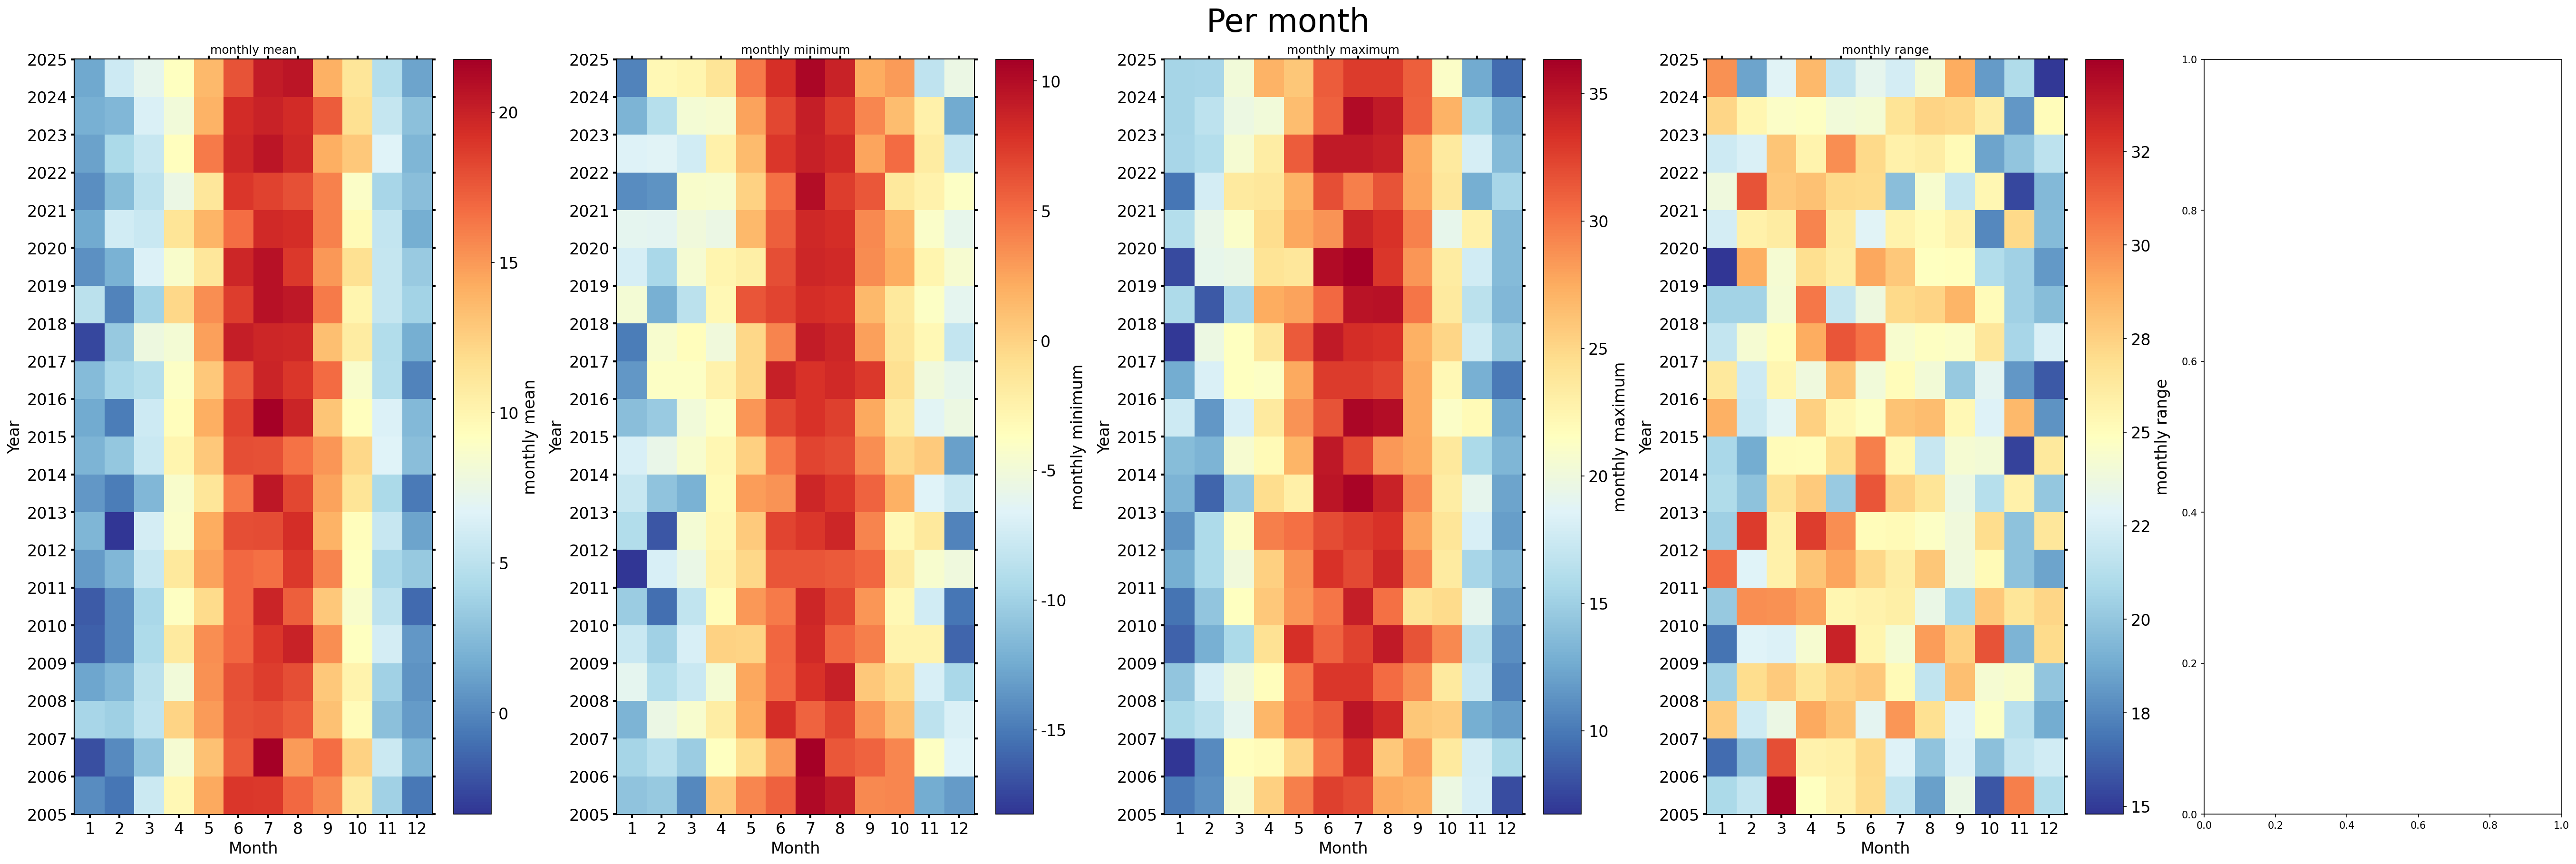

In [6]:
fig, axs = plt.subplots(ncols=5, figsize=(36, 12), dpi=150, layout="constrained")
fig.suptitle(f'Per month', fontsize=32)
HeatmapYearMonth(series_monthly=ta.resample('M').mean(), title="monthly mean", ax=axs[0], cb_digits_after_comma=0, zlabel="monthly mean").plot()
HeatmapYearMonth(series_monthly=ta.resample('M').min(), title="monthly minimum", ax=axs[1], cb_digits_after_comma=0, zlabel="monthly minimum").plot()
HeatmapYearMonth(series_monthly=ta.resample('M').max(), title="monthly maximum", ax=axs[2], cb_digits_after_comma=0, zlabel="monthly maximum").plot()
_range = ta.resample('M').max().sub(df['TA_T1_2_1'].resample('M').min())
HeatmapYearMonth(series_monthly=_range, title="monthly range", ax=axs[3], cb_digits_after_comma=0, zlabel="monthly range").plot()

## Averages up to respective DOY

In [7]:
plotdf = pd.DataFrame(ta).copy()
plotdf = plotdf.resample('D').mean()
plotdf['DOY'] = plotdf.index.date
plotdf['DOY'] = pd.to_datetime(plotdf['DOY']).dt.dayofyear
plotdf

,TA_T1_2_1,DOY
TIMESTAMP_MIDDLE,,
2005-01-01,3.548611,1
2005-01-02,5.244444,2
2005-01-03,3.306944,3
2005-01-04,0.831250,4
2005-01-05,1.537500,5
...,...,...
2024-12-27,-1.162517,362
2024-12-28,-1.746727,363
2024-12-29,-1.868071,364


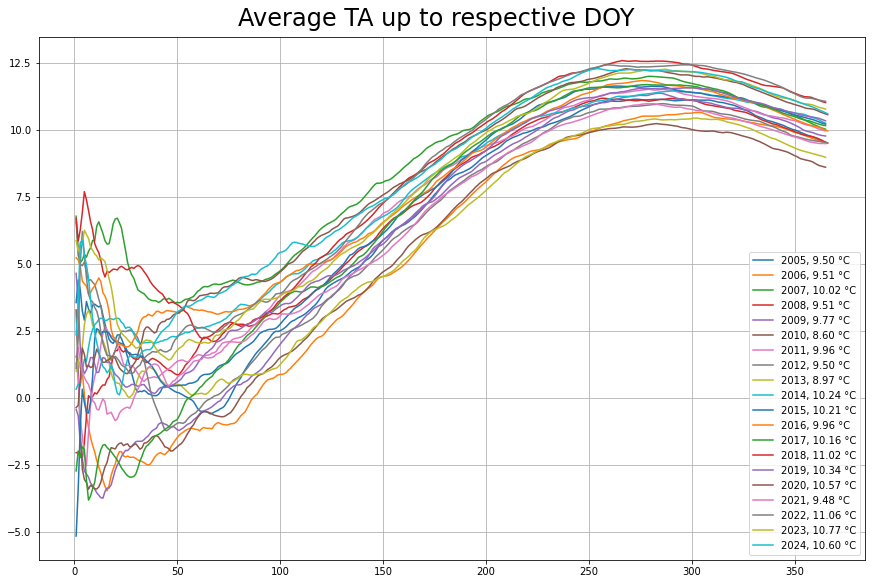

In [8]:
allyears = pd.DataFrame()
counter = 0
for year in range (2005, 2025, 1):
    counter += 1
    locs = plotdf.index.year == year
    yeardf = plotdf[locs].copy()
    yeardf['CUMSUM'] = yeardf[ta_col].cumsum()  
    yeardf['avg'] = yeardf['CUMSUM'].divide(yeardf['DOY'])
    if counter == 1:
        allyears = yeardf.copy()
    else:
        allyears = pd.concat([allyears, yeardf], axis=0)

fig, ax = plt.subplots(ncols=1, figsize=(12, 8), dpi=72, layout="constrained")
fig.suptitle("Average TA up to respective DOY", fontsize=24)

grouped = allyears.groupby(allyears.index.year)
for ix, groupdf in grouped:
    yearlyavg = groupdf["avg"].iloc[-1]
    ax.plot(groupdf["DOY"], groupdf["avg"], label=f"{ix}, {yearlyavg:.2f} °C")
    # groupdf.plot()
    # print(groupdf)
ax.grid()
ax.legend();

# Stats

## Yearly averages

In [9]:
ta.resample('YE').mean()

TIMESTAMP_MIDDLE
2005-12-31     9.500346
2006-12-31     9.510808
2007-12-31    10.020665
2008-12-31     9.509768
2009-12-31     9.768376
2010-12-31     8.602752
2011-12-31     9.961233
2012-12-31     9.500586
2013-12-31     8.972617
2014-12-31    10.243456
2015-12-31    10.214341
2016-12-31     9.959387
2017-12-31    10.158153
2018-12-31    11.020365
2019-12-31    10.336325
2020-12-31    10.566112
2021-12-31     9.480925
2022-12-31    11.064683
2023-12-31    10.773193
2024-12-31    10.599748
Freq: YE-DEC, Name: TA_T1_2_1, dtype: float64

## Monthly averages

In [17]:
tadf = pd.DataFrame(ta)
tadf['MONTH'] = tadf.index.month
tadf['YEAR'] = tadf.index.year
monthly_avg = tadf.groupby(['YEAR', 'MONTH'])[ta_col].mean().unstack()
monthly_avg

MONTH,1,2,3,4,5,6,7,8,9,10,11,12
YEAR,,,,,,,,,,,,
2005,0.210125,-0.801339,5.713844,9.710972,14.313306,18.916042,18.890143,16.856317,15.635251,10.819029,3.717182,-0.651789
2006,-2.325830,0.080485,3.055509,8.319310,13.250669,17.499912,21.749708,14.987129,16.731619,12.433040,5.730513,2.035287
2007,4.028546,3.698813,5.171103,12.285550,14.959564,17.783585,17.990020,17.422618,13.303557,9.495752,2.811688,0.882221
2008,1.432444,2.281177,4.975142,8.107183,15.310608,17.852078,18.675324,17.944528,12.829824,10.133216,3.764944,0.490034
2009,-1.625389,0.180946,4.377160,10.899647,15.477443,17.023732,18.993706,19.916496,15.428819,9.176833,6.090314,0.687469
2010,-1.816758,0.199619,4.099154,9.068338,11.873036,16.897946,19.849270,17.293014,12.834795,8.677442,5.026717,-1.278987
2011,0.892078,2.255540,5.476857,11.008608,14.657345,16.901711,16.594692,18.906124,15.817371,9.197266,4.117070,3.222475
2012,2.219987,-3.364431,6.058907,8.741281,14.288917,17.940666,18.116941,19.327690,13.941950,9.350884,5.471329,1.343973
2013,0.716500,-0.510813,2.303841,8.682419,11.226284,16.235882,20.530431,18.248934,14.630326,11.306503,4.210245,-0.573077


## Monthly averages: ranks

In [11]:
# Calculate ranks per month
monthly_avg_ranked = monthly_avg.copy()  # Create a copy to avoid modifying the original

def rank_monthly_averages(col):
    return col.rank(method='dense', ascending=False)

monthly_avg_ranked = monthly_avg_ranked.apply(rank_monthly_averages, axis=0)
monthly_avg_ranked

MONTH,1,2,3,4,5,6,7,8,9,10,11,12
YEAR,,,,,,,,,,,,
2005,16.0,19.0,7.0,7.0,8.0,6.0,14.0,18.0,8.0,8.0,19.0,19.0
2006,19.0,15.0,19.0,16.0,14.0,14.0,2.0,20.0,3.0,2.0,5.0,9.0
2007,2.0,5.0,12.0,1.0,5.0,13.0,18.0,16.0,17.0,13.0,20.0,14.0
2008,10.0,10.0,14.0,18.0,4.0,11.0,15.0,14.0,20.0,10.0,18.0,16.0
2009,17.0,14.0,16.0,5.0,2.0,16.0,13.0,3.0,9.0,17.0,4.0,15.0
2010,18.0,13.0,17.0,11.0,17.0,18.0,9.0,17.0,19.0,20.0,11.0,20.0
2011,12.0,11.0,11.0,4.0,7.0,17.0,20.0,11.0,7.0,16.0,16.0,3.0
2012,4.0,20.0,5.0,13.0,9.0,10.0,17.0,9.0,15.0,14.0,6.0,12.0
2013,13.0,17.0,20.0,14.0,18.0,20.0,6.0,13.0,12.0,6.0,15.0,18.0


In [12]:
# Convert to long-form
long_form_df = pd.melt(monthly_avg_ranked, var_name='MONTH', value_name='RANK', ignore_index=False)
long_form_df.reset_index(inplace=True)
long_form_df = long_form_df.rename(columns={'YEAR': 'YEAR'})
long_form_df

,YEAR,MONTH,RANK
0,2005,1,16.0
1,2006,1,19.0
2,2007,1,2.0
3,2008,1,10.0
4,2009,1,17.0
...,...,...,...
235,2020,12,10.0
236,2021,12,6.0
237,2022,12,8.0
238,2023,12,4.0


In [13]:
long_form_df['TIMESTAMP_START'] = long_form_df['YEAR'].astype(str) + '-' + long_form_df['MONTH'].astype(str) + '-' + '01'
long_form_df['TIMESTAMP_START'] = pd.to_datetime(long_form_df['TIMESTAMP_START'])
long_form_df = long_form_df.drop(['YEAR', 'MONTH'], axis=1)
long_form_df = long_form_df.set_index('TIMESTAMP_START')
long_form_df = long_form_df.sort_index()
series_monthly = long_form_df['RANK']
series_monthly = series_monthly.astype(int)
series_monthly.index.freq = 'MS'
series_monthly

TIMESTAMP_START
2005-01-01    16
2005-02-01    19
2005-03-01     7
2005-04-01     7
2005-05-01     8
              ..
2024-08-01     1
2024-09-01    14
2024-10-01     7
2024-11-01    13
2024-12-01    13
Freq: MS, Name: RANK, Length: 240, dtype: int64

## Heatmap: monthly ranks

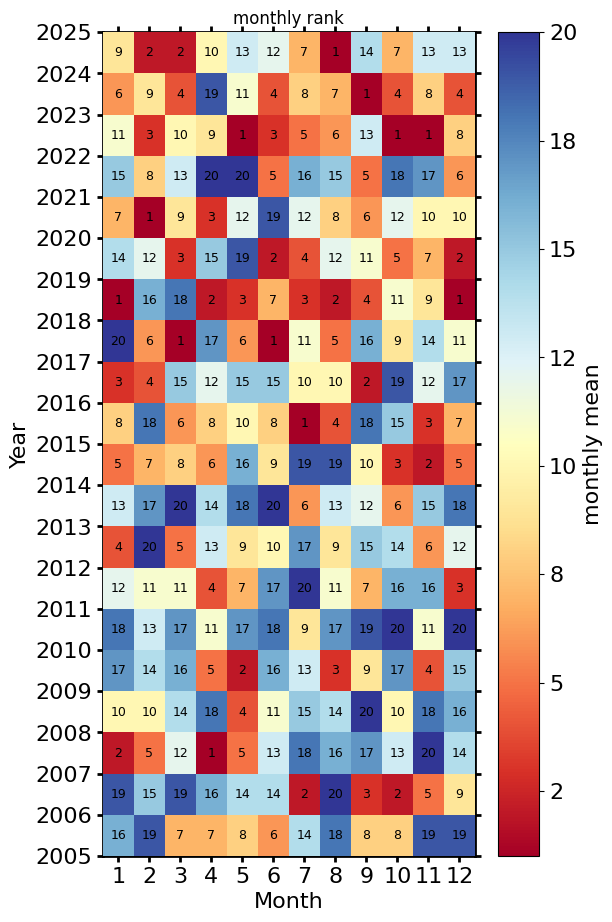

In [16]:
hm = HeatmapYearMonth(series_monthly=series_monthly, title="monthly rank", cb_digits_after_comma=0, zlabel="monthly mean", cmap="RdYlBu", show_values=True, show_values_n_dec_places=0)
hm.plot()

## Mean ranks per year

In [18]:
monthly_avg_ranked.mean(axis=1)

YEAR
2005    12.416667
2006    11.500000
2007    11.333333
2008    13.333333
2009    10.916667
2010    15.833333
2011    11.250000
2012    11.166667
2013    14.333333
2014     9.083333
2015     8.833333
2016    11.166667
2017     9.750000
2018     6.416667
2019     8.833333
2020     9.083333
2021    13.166667
2022     5.916667
2023     7.083333
2024     8.583333
dtype: float64

## Number of days below 0°C

,TA_T1_2_1,YEAR
TIMESTAMP_MIDDLE,,
2005,94,2005
2006,107,2006
2007,100,2007
2008,112,2008
2009,107,2009
2010,118,2010
2011,98,2011
2012,100,2012
2013,113,2013


Average per year: 97.9 +/- 10.57 SD


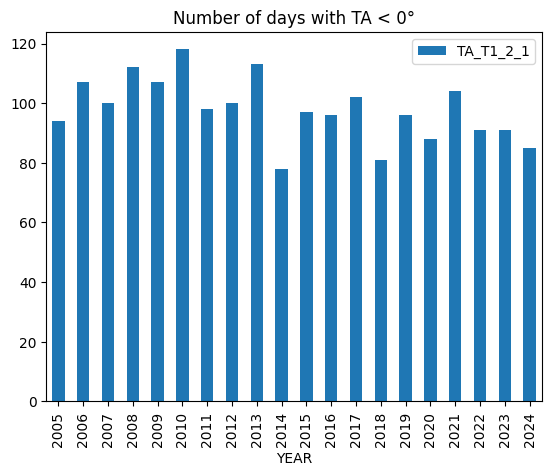

In [19]:
ta = "TA_T1_2_1"
plotdf = df[[ta]].copy()
plotdf = plotdf.resample('D').min()
belowzero = plotdf.loc[plotdf[ta] < 0].copy()
belowzero = belowzero.groupby(belowzero.index.year).count()
belowzero["YEAR"] = belowzero.index
belowzero
belowzero.plot.bar(x="YEAR", y=ta, title="Number of days with TA < 0°");
display(belowzero)
print(f"Average per year: {belowzero[ta].mean()} +/- {belowzero[ta].std():.2f} SD")

## Number of days above 30°C

,TA_T1_2_1,YEAR
TIMESTAMP_MIDDLE,,
2005,8,2005
2006,17,2006
2007,9,2007
2008,12,2008
2009,18,2009
2010,14,2010
2011,10,2011
2012,13,2012
2013,14,2013


Average per year: 16.45 +/- 6.89 SD


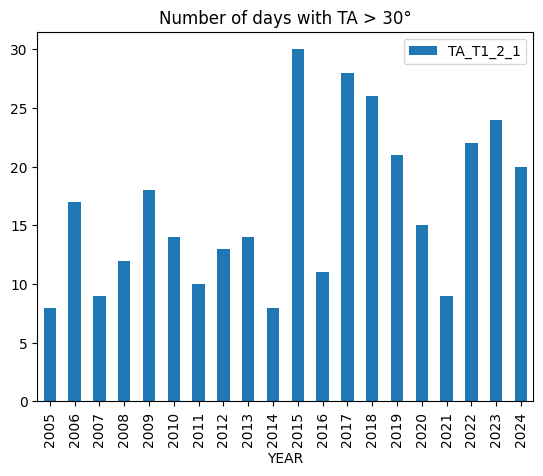

In [20]:
ta = "TA_T1_2_1"
plotdf = df[[ta]].copy()
plotdf = plotdf.resample('D').max()
above = plotdf.loc[plotdf[ta] > 30].copy()
above = above.groupby(above.index.year).count()
above["YEAR"] = above.index
above.plot.bar(x="YEAR", y=ta, title="Number of days with TA > 30°");
display(above)
print(f"Average per year: {above[ta].mean()} +/- {above[ta].std():.2f} SD")

# **End of notebook**

In [21]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-03-21 17:53:42
